<a href="https://colab.research.google.com/github/jjpique29-source/Trabajos-Machine-learning-802/blob/main/knn_ciberseguridad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Clasificador KNN — Incidentes de Ciberseguridad
**Actividad:** Clasificación mediante K Vecinos Más Cercanos y Embeddings de Texto

**Clases del dataset:** `phishing` · `malware` · `ataque_ddos` · `acceso_no_autorizado` · `fuga_datos` · `ingenieria_social`

**Métricas implementadas:** Similitud del Coseno · Distancia L1 · Distancia L2 · Distancia Minkowski

**Librerías usadas:** `sentence-transformers`, `csv`, `random`, `matplotlib.pyplot`

---

##  Paso 1 — Instalación de dependencias

In [ ]:
!pip install sentence-transformers -q

##  Paso 2 — Importaciones permitidas

In [ ]:
import csv
import random
from sentence_transformers import SentenceTransformer
from matplotlib import pyplot as plt

print('✔ Librerías importadas correctamente')

✔ Librerías importadas correctamente


## Paso 3 — Dataset de Ciberseguridad

El dataset contiene **90 muestras** distribuidas en **6 clases** (15 por clase).
Cada muestra es una tupla `(texto_del_incidente, clase)`.

In [ ]:
dataset_ciberseguridad = [

    # --- PHISHING ---
    ("Un empleado recibió un correo que imitaba al banco solicitando actualizar sus credenciales mediante un enlace falso.", "phishing"),
    ("Se detectó un mensaje que aparentaba ser de soporte técnico pidiendo verificar la contraseña en un sitio externo.", "phishing"),
    ("Usuarios reportaron correos urgentes solicitando cambiar datos de acceso a través de un enlace sospechoso.", "phishing"),
    ("Un atacante envió un correo simulando ser el administrador para que los usuarios ingresaran sus credenciales.", "phishing"),
    ("Se identificó una campaña de correos falsos con enlaces que redirigen a páginas de inicio de sesión fraudulentas.", "phishing"),
    ("El mensaje contenía un archivo adjunto y un enlace que solicitaba autenticación en una página clonada.", "phishing"),
    ("Varias cuentas fueron comprometidas tras ingresar credenciales en un sitio que imitaba el portal institucional.", "phishing"),
    ("El correo advertía sobre un bloqueo de cuenta y solicitaba validación inmediata mediante un enlace externo.", "phishing"),
    ("Un usuario cayó en un engaño al ingresar sus datos en un formulario que simulaba el sistema oficial.", "phishing"),
    ("Se distribuyeron mensajes con apariencia legítima que dirigían a páginas falsas para capturar contraseñas.", "phishing"),
    ("El ataque utilizó suplantación de identidad en correos electrónicos para engañar a los usuarios.", "phishing"),
    ("Los enlaces incluidos en el correo llevaban a dominios similares al original pero con ligeras variaciones.", "phishing"),
    ("El atacante utilizó logos institucionales para aumentar la credibilidad del mensaje fraudulento.", "phishing"),
    ("El correo solicitaba actualizar información sensible bajo la amenaza de suspensión del servicio.", "phishing"),
    ("Se detectaron múltiples intentos de engaño mediante correos con contenido alarmante y enlaces externos.", "phishing"),

    # --- MALWARE ---
    ("Un equipo comenzó a ejecutar procesos desconocidos después de instalar un programa descargado de internet.", "malware"),
    ("Se detectó software malicioso que cifra archivos y solicita un pago para recuperarlos.", "malware"),
    ("El sistema mostró actividad anormal tras abrir un archivo adjunto proveniente de un correo sospechoso.", "malware"),
    ("Un programa no autorizado se instaló en segundo plano y comenzó a consumir recursos del sistema.", "malware"),
    ("Se identificó un troyano que permite el acceso remoto al equipo infectado.", "malware"),
    ("El antivirus detectó código malicioso que intentaba propagarse a través de la red local.", "malware"),
    ("Archivos importantes fueron modificados sin autorización después de ejecutar un software desconocido.", "malware"),
    ("El equipo presentó lentitud extrema debido a la ejecución de procesos ocultos.", "malware"),
    ("Se encontró un script malicioso que recolectaba información del usuario sin su consentimiento.", "malware"),
    ("Un programa aparentemente legítimo instaló componentes ocultos en el sistema.", "malware"),
    ("Se detectó actividad persistente en el sistema incluso después de reiniciar el equipo.", "malware"),
    ("El software instalado comenzó a enviar información a servidores externos sin autorización.", "malware"),
    ("El sistema descargó automáticamente archivos sospechosos tras visitar una página web.", "malware"),
    ("Se evidenció comportamiento típico de ransomware tras la ejecución de un archivo desconocido.", "malware"),
    ("Un proceso oculto intentaba desactivar las herramientas de seguridad del sistema.", "malware"),

    # --- ATAQUE_DDOS ---
    ("El servidor web dejó de responder debido a un alto volumen de solicitudes simultáneas.", "ataque_ddos"),
    ("Se registró un tráfico inusualmente elevado que saturó la capacidad del sistema.", "ataque_ddos"),
    ("El servicio fue interrumpido por múltiples conexiones provenientes de diferentes direcciones IP.", "ataque_ddos"),
    ("Se detectó un incremento abrupto de peticiones que causó la caída del servidor.", "ataque_ddos"),
    ("El sistema experimentó lentitud extrema debido a un flujo masivo de tráfico entrante.", "ataque_ddos"),
    ("Se identificó un patrón de solicitudes repetitivas que consumían todos los recursos disponibles.", "ataque_ddos"),
    ("El sitio web se volvió inaccesible tras recibir miles de peticiones por segundo.", "ataque_ddos"),
    ("Los logs muestran múltiples accesos simultáneos desde ubicaciones geográficas diversas.", "ataque_ddos"),
    ("La infraestructura colapsó por una sobrecarga de conexiones externas coordinadas.", "ataque_ddos"),
    ("Se evidenció un ataque distribuido que saturó los servicios de red.", "ataque_ddos"),
    ("El sistema dejó de atender usuarios legítimos debido a la saturación del tráfico.", "ataque_ddos"),
    ("Se registraron picos anormales de tráfico que afectaron la disponibilidad del servicio.", "ataque_ddos"),
    ("Las peticiones automatizadas superaron la capacidad de respuesta del servidor.", "ataque_ddos"),
    ("El ataque generó congestión en la red impidiendo el acceso normal al sistema.", "ataque_ddos"),
    ("Se detectaron múltiples bots generando tráfico excesivo hacia el sistema.", "ataque_ddos"),

    # --- ACCESO_NO_AUTORIZADO ---
    ("Se detectó un inicio de sesión desde una ubicación desconocida sin autorización del usuario.", "acceso_no_autorizado"),
    ("Un usuario accedió a información restringida sin contar con los permisos adecuados.", "acceso_no_autorizado"),
    ("Se registraron intentos de acceso repetidos utilizando credenciales incorrectas.", "acceso_no_autorizado"),
    ("Un atacante logró ingresar al sistema utilizando credenciales robadas.", "acceso_no_autorizado"),
    ("Se detectó actividad sospechosa en una cuenta fuera de su horario habitual.", "acceso_no_autorizado"),
    ("Un usuario accedió a recursos críticos sin haber sido autorizado previamente.", "acceso_no_autorizado"),
    ("Se evidenció acceso a la base de datos desde una IP no registrada.", "acceso_no_autorizado"),
    ("El sistema registró múltiples intentos fallidos seguidos de un acceso exitoso.", "acceso_no_autorizado"),
    ("Se observó uso indebido de privilegios en una cuenta comprometida.", "acceso_no_autorizado"),
    ("Un usuario logró escalar privilegios dentro del sistema sin autorización.", "acceso_no_autorizado"),
    ("Se detectó acceso a información sensible desde un dispositivo no reconocido.", "acceso_no_autorizado"),
    ("El sistema alertó sobre autenticaciones sospechosas en varias cuentas.", "acceso_no_autorizado"),
    ("Se evidenció manipulación de datos por parte de un usuario no autorizado.", "acceso_no_autorizado"),
    ("Un acceso remoto no autorizado permitió la consulta de información confidencial.", "acceso_no_autorizado"),
    ("Se detectó uso indebido de credenciales para ingresar a sistemas restringidos.", "acceso_no_autorizado"),

    # --- FUGA_DATOS ---
    ("Se detectó transferencia de información confidencial hacia un servidor externo.", "fuga_datos"),
    ("Archivos sensibles fueron enviados fuera de la organización sin autorización.", "fuga_datos"),
    ("Se identificó exfiltración de datos mediante conexiones no seguras.", "fuga_datos"),
    ("Un usuario descargó grandes volúmenes de información antes de abandonar la empresa.", "fuga_datos"),
    ("Se evidenció salida de datos críticos hacia direcciones IP desconocidas.", "fuga_datos"),
    ("Información privada fue copiada y transferida sin controles adecuados.", "fuga_datos"),
    ("Se detectó envío masivo de datos hacia servicios en la nube no autorizados.", "fuga_datos"),
    ("Archivos internos aparecieron publicados en plataformas externas.", "fuga_datos"),
    ("Se identificó actividad inusual de descarga de datos sensibles.", "fuga_datos"),
    ("El sistema registró exportaciones de información fuera de los canales permitidos.", "fuga_datos"),
    ("Datos confidenciales fueron compartidos a través de medios no seguros.", "fuga_datos"),
    ("Se evidenció pérdida de información crítica por falta de controles de seguridad.", "fuga_datos"),
    ("El tráfico de salida mostró patrones asociados a exfiltración de datos.", "fuga_datos"),
    ("Se detectó copia de bases de datos completas hacia dispositivos externos.", "fuga_datos"),
    ("Información restringida fue transferida sin autorización fuera del entorno seguro.", "fuga_datos"),

    # --- INGENIERIA_SOCIAL ---
    ("Un atacante se hizo pasar por un técnico para obtener credenciales directamente del usuario.", "ingenieria_social"),
    ("Se reportó una llamada en la que alguien solicitaba información confidencial haciéndose pasar por soporte.", "ingenieria_social"),
    ("Un individuo logró acceso físico al sistema engañando al personal de seguridad.", "ingenieria_social"),
    ("El atacante manipuló a un empleado para que revelara información sensible.", "ingenieria_social"),
    ("Se utilizó presión psicológica para obtener acceso a sistemas restringidos.", "ingenieria_social"),
    ("Un usuario fue convencido de compartir su contraseña mediante una conversación engañosa.", "ingenieria_social"),
    ("El atacante utilizó pretextos creíbles para obtener acceso a información confidencial.", "ingenieria_social"),
    ("Se detectó manipulación directa del personal para evadir controles de seguridad.", "ingenieria_social"),
    ("Un supuesto proveedor solicitó acceso alegando urgencia operativa.", "ingenieria_social"),
    ("El atacante aprovechó la confianza del usuario para obtener información crítica.", "ingenieria_social"),
    ("Se evidenció engaño directo sin uso de herramientas técnicas para acceder al sistema.", "ingenieria_social"),
    ("Un intruso logró acceso mediante interacción social en lugar de vulnerar sistemas.", "ingenieria_social"),
    ("El ataque se basó en persuadir al usuario para omitir protocolos de seguridad.", "ingenieria_social"),
    ("Se utilizó identidad falsa para obtener privilegios dentro de la organización.", "ingenieria_social"),
    ("El atacante manipuló emocionalmente al usuario para obtener acceso al sistema.", "ingenieria_social")
]

# ── Extraer textos y clases ────────────────────────────────────────────────────
textos = [muestra[0] for muestra in dataset_ciberseguridad]
clases = [muestra[1] for muestra in dataset_ciberseguridad]
clases_unicas = list(set(clases))

print(f'✔ Total de muestras  : {len(textos)}')
print(f'✔ Clases encontradas : {clases_unicas}')
print(f'\nMuestra de 2 registros por clase:')
mostrados = {}
for txt, cls in zip(textos, clases):
    if mostrados.get(cls, 0) < 2:
        print(f'  [{cls}]  {txt[:75]}...')
        mostrados[cls] = mostrados.get(cls, 0) + 1

✔ Total de muestras  : 90
✔ Clases encontradas : ['ataque_ddos', 'acceso_no_autorizado', 'phishing', 'malware', 'ingenieria_social', 'fuga_datos']

Muestra de 2 registros por clase:
  [phishing]  Un empleado recibió un correo que imitaba al banco solicitando actualizar s...
  [phishing]  Se detectó un mensaje que aparentaba ser de soporte técnico pidiendo verifi...
  [malware]  Un equipo comenzó a ejecutar procesos desconocidos después de instalar un p...
  [malware]  Se detectó software malicioso que cifra archivos y solicita un pago para re...
  [ataque_ddos]  El servidor web dejó de responder debido a un alto volumen de solicitudes s...
  [ataque_ddos]  Se registró un tráfico inusualmente elevado que saturó la capacidad del sis...
  [acceso_no_autorizado]  Se detectó un inicio de sesión desde una ubicación desconocida sin autoriza...
  [acceso_no_autorizado]  Un usuario accedió a información restringida sin contar con los permisos ad...
  [fuga_datos]  Se detectó transferencia de in

##  Paso 4 — Distribución de clases

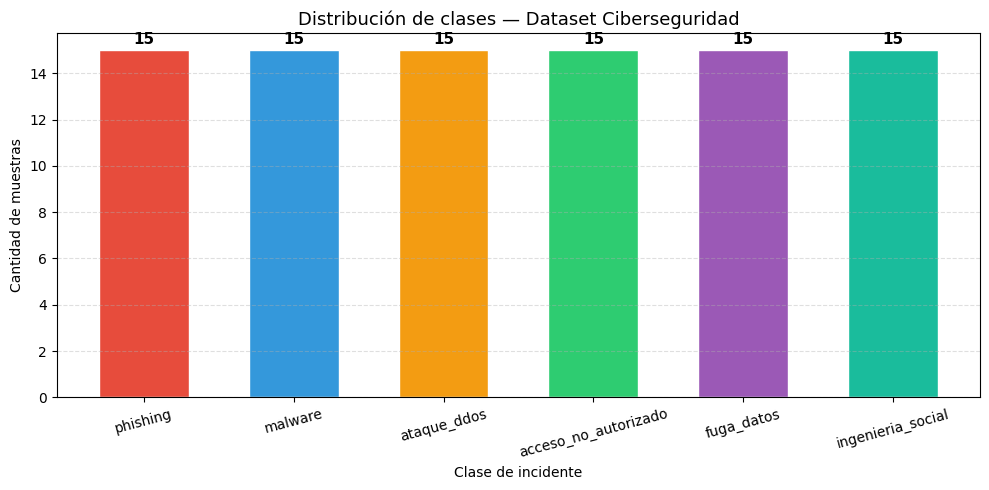

In [ ]:
def graficar_distribucion_clases(clases):
    conteo = {}
    for c in clases:
        conteo[c] = conteo.get(c, 0) + 1

    etiquetas = list(conteo.keys())
    valores   = [conteo[e] for e in etiquetas]
    colores   = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71', '#9b59b6', '#1abc9c']

    fig, ax = plt.subplots(figsize=(10, 5))
    barras = ax.bar(etiquetas, valores, color=colores[:len(etiquetas)],
                    edgecolor='white', width=0.6)
    for barra, val in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width() / 2,
                barra.get_height() + 0.15, str(val),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title('Distribución de clases — Dataset Ciberseguridad', fontsize=13)
    ax.set_xlabel('Clase de incidente')
    ax.set_ylabel('Cantidad de muestras')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


graficar_distribucion_clases(clases)

## Paso 5 — Generación de Embeddings
Cada texto se convierte en un vector numérico de **384 dimensiones** usando `sentence-transformers`.
El modelo `paraphrase-multilingual-MiniLM-L12-v2` es multilingüe y funciona bien con textos en español.

In [ ]:
MODELO_EMB = 'paraphrase-multilingual-MiniLM-L12-v2'   # Multilingüe — ideal para español


def generar_embeddings(textos, nombre_modelo):
    """
    Convierte una lista de textos en vectores numéricos (embeddings)
    usando el modelo de sentence-transformers indicado.
    Devuelve una lista de listas de floats.
    """
    modelo = SentenceTransformer(nombre_modelo)
    vectores = modelo.encode(textos, show_progress_bar=True)
    return [v.tolist() for v in vectores]


print('Generando embeddings para los 90 textos...')
embeddings = generar_embeddings(textos, MODELO_EMB)
print(f'\n✔ Embeddings generados')
print(f'  Número de vectores   : {len(embeddings)}')
print(f'  Dimensión del vector : {len(embeddings[0])}')

Generando embeddings para los 90 textos...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]


✔ Embeddings generados
  Número de vectores   : 90
  Dimensión del vector : 384


##  Paso 6 — Métricas de distancia y similitud (implementadas desde cero)

Todas las fórmulas usan únicamente operaciones Python puras — sin librerías externas.

In [ ]:
# ── Similitud del Coseno ───────────────────────────────────────────────────────
def similitud_coseno(v1, v2):
    """
    Similitud del Coseno entre dos vectores.
    Fórmula: cos(θ) = (v1 · v2) / (||v1|| × ||v2||)

    Rango: [-1, 1]  →  1 = idénticos | 0 = perpendiculares | -1 = opuestos.
    Para KNN: mayor similitud → vecino más cercano.
    Ideal para textos: mide orientación del vector, no su magnitud.
    """
    producto_punto = sum(a * b for a, b in zip(v1, v2))
    norma_v1 = sum(a ** 2 for a in v1) ** 0.5
    norma_v2 = sum(b ** 2 for b in v2) ** 0.5
    if norma_v1 == 0.0 or norma_v2 == 0.0:
        return 0.0
    return producto_punto / (norma_v1 * norma_v2)


# ── Distancia de Minkowski ─────────────────────────────────────────────────────
def distancia_minkowski(v1, v2, p=3):
    """
    Distancia de Minkowski con parámetro p.
    Fórmula: ( Σ |v1_i - v2_i|^p )^(1/p)

    p=1 → Manhattan (L1) | p=2 → Euclidiana (L2) | p>2 → sensible a outliers.
    Para KNN: menor distancia → vecino más cercano.
    """
    return sum(abs(a - b) ** p for a, b in zip(v1, v2)) ** (1.0 / p)


# ── Distancia L1 (Manhattan) ───────────────────────────────────────────────────
def distancia_l1(v1, v2):
    """
    Distancia Manhattan (L1) — caso especial de Minkowski con p=1.
    Fórmula: Σ |v1_i - v2_i|

    Robusta ante valores atípicos.
    Suma diferencias absolutas componente a componente.
    Para KNN: menor distancia → vecino más cercano.
    """
    return sum(abs(a - b) for a, b in zip(v1, v2))


# ── Distancia L2 (Euclidiana) ──────────────────────────────────────────────────
def distancia_l2(v1, v2):
    """
    Distancia Euclidiana (L2) — caso especial de Minkowski con p=2.
    Fórmula: sqrt( Σ (v1_i - v2_i)² )

    La distancia 'en línea recta' en el espacio vectorial.
    Para KNN: menor distancia → vecino más cercano.
    """
    return sum((a - b) ** 2 for a, b in zip(v1, v2)) ** 0.5


# ── Test rápido de verificación ────────────────────────────────────────────────
v1_test = [1.0, 0.0, 0.5, -0.3]
v2_test = [0.8, 0.2, 0.4, -0.1]

print('=== Verificación de métricas ===')
print(f'Similitud Coseno  : {similitud_coseno(v1_test, v2_test):.4f}')
print(f'Distancia L1      : {distancia_l1(v1_test, v2_test):.4f}')
print(f'Distancia L2      : {distancia_l2(v1_test, v2_test):.4f}')
print(f'Minkowski p=3     : {distancia_minkowski(v1_test, v2_test, 3):.4f}')
print(f'Minkowski p=1     : {distancia_minkowski(v1_test, v2_test, 1):.4f}  (= L1 ✔)')
print(f'Minkowski p=2     : {distancia_minkowski(v1_test, v2_test, 2):.4f}  (= L2 ✔)')

=== Verificación de métricas ===
Similitud Coseno  : 0.9651
Distancia L1      : 0.7000
Distancia L2      : 0.3606
Minkowski p=3     : 0.2924
Minkowski p=1     : 0.7000  (= L1 ✔)
Minkowski p=2     : 0.3606  (= L2 ✔)


##  Paso 7 — Algoritmo KNN

In [ ]:
def calcular_distancia(v1, v2, metrica, p_minkowski=3):
    """
    Despacha al cálculo de distancia/similitud según la métrica elegida.
    Devuelve siempre un valor donde MENOR = más cercano:
      - Coseno    → devuelve 1 - similitud (inversión para uniformidad)
      - L1 / L2 / Minkowski → devuelve la distancia directamente
    """
    if metrica == 'coseno':
        return 1.0 - similitud_coseno(v1, v2)
    elif metrica == 'l1':
        return distancia_l1(v1, v2)
    elif metrica == 'l2':
        return distancia_l2(v1, v2)
    elif metrica == 'minkowski':
        return distancia_minkowski(v1, v2, p=p_minkowski)
    else:
        raise ValueError(f"Métrica no reconocida: '{metrica}'")


def knn_clasificar(emb_consulta, embeddings_train, clases_train, textos_train,
                   k, metrica, p_minkowski=3):
    """
    Clasifica un embedding de consulta usando el algoritmo KNN.

    Parámetros:
      emb_consulta    : vector del texto a clasificar
      embeddings_train: vectores del conjunto de entrenamiento
      clases_train    : etiquetas del conjunto de entrenamiento
      textos_train    : textos originales (para visualización)
      k               : número de vecinos
      metrica         : 'coseno' | 'l1' | 'l2' | 'minkowski'
      p_minkowski     : parámetro p para Minkowski

    Retorna:
      clase_predicha  : clase ganadora por votación
      detalle_vecinos : lista con info de los K vecinos
      votos           : diccionario de conteo por clase
    """
    # Paso 1: Calcular distancia a cada ejemplo de entrenamiento
    distancias = []
    for idx in range(len(embeddings_train)):
        dist = calcular_distancia(emb_consulta, embeddings_train[idx],
                                  metrica, p_minkowski)
        distancias.append((dist, idx))

    # Paso 2: Ordenar de menor a mayor (burbuja — sin librerías externas)
    n = len(distancias)
    for i in range(n):
        for j in range(0, n - i - 1):
            if distancias[j][0] > distancias[j + 1][0]:
                distancias[j], distancias[j + 1] = distancias[j + 1], distancias[j]

    # Paso 3: Seleccionar los K vecinos más cercanos
    vecinos_k = distancias[:k]

    # Paso 4: Construir detalle de cada vecino
    detalle_vecinos = []
    for dist, idx in vecinos_k:
        if metrica == 'coseno':
            etiqueta_valor = f'sim={1.0 - dist:.4f}'
        else:
            etiqueta_valor = f'd={dist:.4f}'
        detalle_vecinos.append({
            'indice'        : idx,
            'clase'         : clases_train[idx],
            'texto'         : textos_train[idx],
            'distancia'     : dist,
            'etiqueta_valor': etiqueta_valor
        })

    # Paso 5: Votación por mayoría
    votos = {}
    for vecino in detalle_vecinos:
        clase = vecino['clase']
        votos[clase] = votos.get(clase, 0) + 1

    clase_predicha = max(votos, key=lambda c: votos[c])
    return clase_predicha, detalle_vecinos, votos


print('✔ Funciones KNN definidas correctamente')

✔ Funciones KNN definidas correctamente


##  Paso 8 — Presentación de resultados

In [ ]:
def mostrar_resultado(mensaje, clase_predicha, vecinos_k, votos, metrica, k):
    ancho = 80
    print('\n' + '═' * ancho)
    print(f'   Mensaje   : {mensaje[:72]}')
    print(f'   Métrica   : {metrica.upper()}   |   K = {k}')
    print('─' * ancho)
    print(f"  {'#':<3} {'Clase':<22} {'Valor':>14}   Texto del vecino")
    print('─' * ancho)
    for rank, vecino in enumerate(vecinos_k, 1):
        texto_corto = (vecino['texto'][:36] + '…'
                       if len(vecino['texto']) > 36 else vecino['texto'])
        print(f"  {rank:<3} {vecino['clase']:<22} {vecino['etiqueta_valor']:>14}   {texto_corto}")
    print('─' * ancho)
    print(f'   Votos     : {votos}')
    print(f'   Predicción : {clase_predicha.upper()}')
    print('═' * ancho)


print('✔ Función de presentación lista')

✔ Función de presentación lista


##  Paso 9 — Evaluación Leave-One-Out (LOO)
Para cada muestra se entrena con las 89 restantes y se predice esa muestra.
Esto mide la precisión real del modelo sin necesidad de un conjunto de prueba separado.

In [ ]:
def evaluar_loo(embeddings, clases, textos, k, metrica, p_minkowski=3):
    """
    Evaluación Leave-One-Out:
    Usa cada muestra como consulta y entrena con las demás.
    Retorna el porcentaje de aciertos.
    """
    correctos = 0
    n = len(embeddings)
    for i in range(n):
        emb_test   = embeddings[i]
        embs_train = embeddings[:i] + embeddings[i + 1:]
        cls_train  = clases[:i]     + clases[i + 1:]
        txts_train = textos[:i]     + textos[i + 1:]

        pred, _, _ = knn_clasificar(emb_test, embs_train, cls_train,
                                    txts_train, k, metrica, p_minkowski)
        if pred == clases[i]:
            correctos += 1

    return round(correctos / n * 100, 2)


# ── Ejecutar evaluación para todas las métricas y valores de K ─────────────────
metricas_eval   = ['coseno', 'l1', 'l2', 'minkowski']
ks_eval         = [1, 3, 5, 7]
resultados_eval = {}

print('Evaluando clasificador con Leave-One-Out (puede tardar ~1-2 min)...\n')
print(f"{'Métrica':<14}  " + '    '.join(f'K={k}' for k in ks_eval))
print('─' * 46)

for metrica in metricas_eval:
    resultados_eval[metrica] = {}
    fila = f'{metrica.upper():<14}  '
    for k in ks_eval:
        prec = evaluar_loo(embeddings, clases, textos, k, metrica)
        resultados_eval[metrica][k] = prec
        fila += f'{prec:>5.1f}%   '
    print(fila)

print('\n✔ Evaluación completada')

Evaluando clasificador con Leave-One-Out (puede tardar ~1-2 min)...

Métrica         K=1    K=3    K=5    K=7
──────────────────────────────────────────────
COSENO           65.6%    72.2%    70.0%    72.2%   
L1               63.3%    66.7%    70.0%    72.2%   
L2               62.2%    67.8%    72.2%    74.4%   
MINKOWSKI        64.4%    71.1%    73.3%    73.3%   

✔ Evaluación completada


##  Paso 10 — Gráfica de evaluación por K y métrica

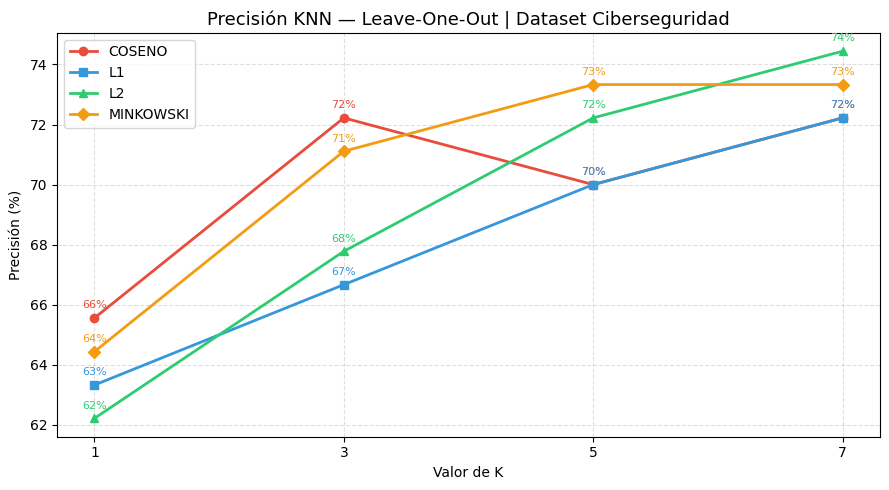

In [ ]:
def graficar_evaluacion(resultados_eval, ks_eval):
    colores    = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
    marcadores = ['o', 's', '^', 'D']

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, (metrica, resultados) in enumerate(resultados_eval.items()):
        precisiones = [resultados[k] for k in ks_eval]
        ax.plot(ks_eval, precisiones,
                marker=marcadores[i % 4],
                color=colores[i % 4],
                linewidth=2,
                label=metrica.upper())
        for k, prec in zip(ks_eval, precisiones):
            ax.annotate(f'{prec:.0f}%', xy=(k, prec),
                        xytext=(0, 7), textcoords='offset points',
                        ha='center', fontsize=8, color=colores[i % 4])

    ax.set_title('Precisión KNN — Leave-One-Out | Dataset Ciberseguridad', fontsize=13)
    ax.set_xlabel('Valor de K')
    ax.set_ylabel('Precisión (%)')
    ax.set_xticks(ks_eval)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


graficar_evaluacion(resultados_eval, ks_eval)

##  Paso 11 — Pruebas con textos de entrada

Se prueban mensajes nuevos de ciberseguridad con las **4 métricas** y distintos valores de **K**.

In [ ]:
# ── Cargar modelo para la sesión de pruebas ────────────────────────────────────
modelo_interactivo = SentenceTransformer(MODELO_EMB)


def clasificar_texto(mensaje, k=3, metrica='coseno', p_minkowski=3):
    """
    Clasifica un mensaje nuevo y muestra el resultado.
    metrica: 'coseno' | 'l1' | 'l2' | 'minkowski'
    """
    emb_nuevo = modelo_interactivo.encode([mensaje])[0].tolist()
    clase_pred, vecinos, votos = knn_clasificar(
        emb_nuevo, embeddings, clases, textos, k, metrica, p_minkowski)
    mostrar_resultado(mensaje, clase_pred, vecinos, votos, metrica, k)
    return clase_pred


print('✔ Función clasificar_texto() lista')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✔ Función clasificar_texto() lista


In [ ]:
# ── Prueba 1: Posible phishing — comparar las 4 métricas ──────────────────────
MENSAJE_1 = 'Recibí un correo del banco pidiendo que actualizara mi contraseña haciendo clic en un enlace'

for metrica in ['coseno', 'l1', 'l2', 'minkowski']:
    clasificar_texto(MENSAJE_1, k=3, metrica=metrica)


════════════════════════════════════════════════════════════════════════════════
   Mensaje   : Recibí un correo del banco pidiendo que actualizara mi contraseña hacien
   Métrica   : COSENO   |   K = 3
────────────────────────────────────────────────────────────────────────────────
  #   Clase                           Valor   Texto del vecino
────────────────────────────────────────────────────────────────────────────────
  1   phishing                   sim=0.6698   Un empleado recibió un correo que im…
  2   phishing                   sim=0.6333   El mensaje contenía un archivo adjun…
  3   phishing                   sim=0.6113   Se detectó un mensaje que aparentaba…
────────────────────────────────────────────────────────────────────────────────
   Votos     : {'phishing': 3}
   Predicción : PHISHING
════════════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════════════
   Mensaje   : Reci

In [ ]:
# ── Prueba 2: Posible malware — comparar las 4 métricas ───────────────────────
MENSAJE_2 = 'Después de abrir un archivo descargado, el equipo comenzó a cifrar todos los documentos y pide un rescate'

for metrica in ['coseno', 'l1', 'l2', 'minkowski']:
    clasificar_texto(MENSAJE_2, k=3, metrica=metrica)


════════════════════════════════════════════════════════════════════════════════
   Mensaje   : Después de abrir un archivo descargado, el equipo comenzó a cifrar todos
   Métrica   : COSENO   |   K = 3
────────────────────────────────────────────────────────────────────────────────
  #   Clase                           Valor   Texto del vecino
────────────────────────────────────────────────────────────────────────────────
  1   malware                    sim=0.5644   Se detectó software malicioso que ci…
  2   malware                    sim=0.5182   El sistema descargó automáticamente …
  3   malware                    sim=0.4936   Un equipo comenzó a ejecutar proceso…
────────────────────────────────────────────────────────────────────────────────
   Votos     : {'malware': 3}
   Predicción : MALWARE
════════════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════════════
   Mensaje   : Despué

In [ ]:
# ── Prueba 3: Posible DDoS — comparar las 4 métricas ──────────────────────────
MENSAJE_3 = 'El servidor dejó de responder por un exceso de peticiones que llegaron al mismo tiempo desde distintos países'

for metrica in ['coseno', 'l1', 'l2', 'minkowski']:
    clasificar_texto(MENSAJE_3, k=3, metrica=metrica)


════════════════════════════════════════════════════════════════════════════════
   Mensaje   : El servidor dejó de responder por un exceso de peticiones que llegaron a
   Métrica   : COSENO   |   K = 3
────────────────────────────────────────────────────────────────────────────────
  #   Clase                           Valor   Texto del vecino
────────────────────────────────────────────────────────────────────────────────
  1   ataque_ddos                sim=0.7799   El servidor web dejó de responder de…
  2   ataque_ddos                sim=0.6916   Las peticiones automatizadas superar…
  3   ataque_ddos                sim=0.6397   Se detectó un incremento abrupto de …
────────────────────────────────────────────────────────────────────────────────
   Votos     : {'ataque_ddos': 3}
   Predicción : ATAQUE_DDOS
════════════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════════════
   Mensaje   

In [ ]:
# ── Prueba 4: Efecto de K con métrica coseno ───────────────────────────────────
MENSAJE_4 = 'Un empleado llamó diciendo ser soporte técnico y convenció al usuario de revelar su clave de acceso'

for k in [1, 3, 5, 7]:
    clasificar_texto(MENSAJE_4, k=k, metrica='coseno')


════════════════════════════════════════════════════════════════════════════════
   Mensaje   : Un empleado llamó diciendo ser soporte técnico y convenció al usuario de
   Métrica   : COSENO   |   K = 1
────────────────────────────────────────────────────────────────────────────────
  #   Clase                           Valor   Texto del vecino
────────────────────────────────────────────────────────────────────────────────
  1   ingenieria_social          sim=0.7048   Un supuesto proveedor solicitó acces…
────────────────────────────────────────────────────────────────────────────────
   Votos     : {'ingenieria_social': 1}
   Predicción : INGENIERIA_SOCIAL
════════════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════════════
   Mensaje   : Un empleado llamó diciendo ser soporte técnico y convenció al usuario de
   Métrica   : COSENO   |   K = 3
───────────────────────────────────────────────

In [ ]:
# ── Prueba 5: Escribe tu propio incidente aquí ─────────────────────────────────
MI_MENSAJE = 'Escribe aquí la descripción del incidente a clasificar'   # <── cambia esto
K          = 3                                                           # <── cambia K
METRICA    = 'coseno'   # opciones: 'coseno' | 'l1' | 'l2' | 'minkowski'

clasificar_texto(MI_MENSAJE, k=K, metrica=METRICA)


════════════════════════════════════════════════════════════════════════════════
   Mensaje   : Escribe aquí la descripción del incidente a clasificar
   Métrica   : COSENO   |   K = 3
────────────────────────────────────────────────────────────────────────────────
  #   Clase                           Valor   Texto del vecino
────────────────────────────────────────────────────────────────────────────────
  1   ingenieria_social          sim=0.4012   El atacante manipuló a un empleado p…
  2   acceso_no_autorizado       sim=0.3878   Se detectó actividad sospechosa en u…
  3   phishing                   sim=0.3564   Se detectaron múltiples intentos de …
────────────────────────────────────────────────────────────────────────────────
   Votos     : {'ingenieria_social': 1, 'acceso_no_autorizado': 1, 'phishing': 1}
   Predicción : INGENIERIA_SOCIAL
════════════════════════════════════════════════════════════════════════════════


'ingenieria_social'

##  Paso 12 — Comparación visual de las 4 métricas para un mismo mensaje

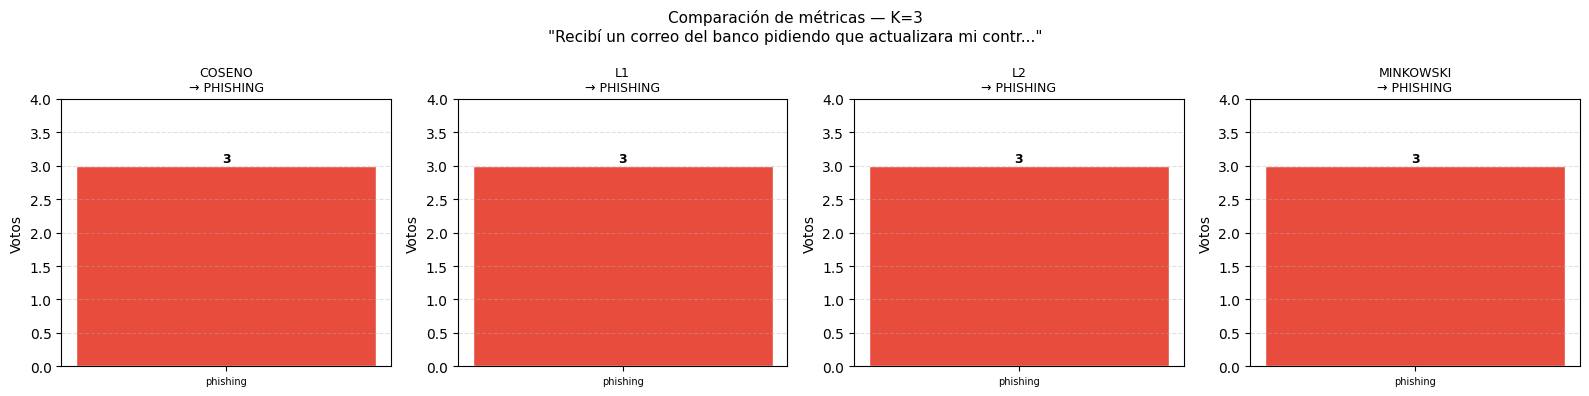

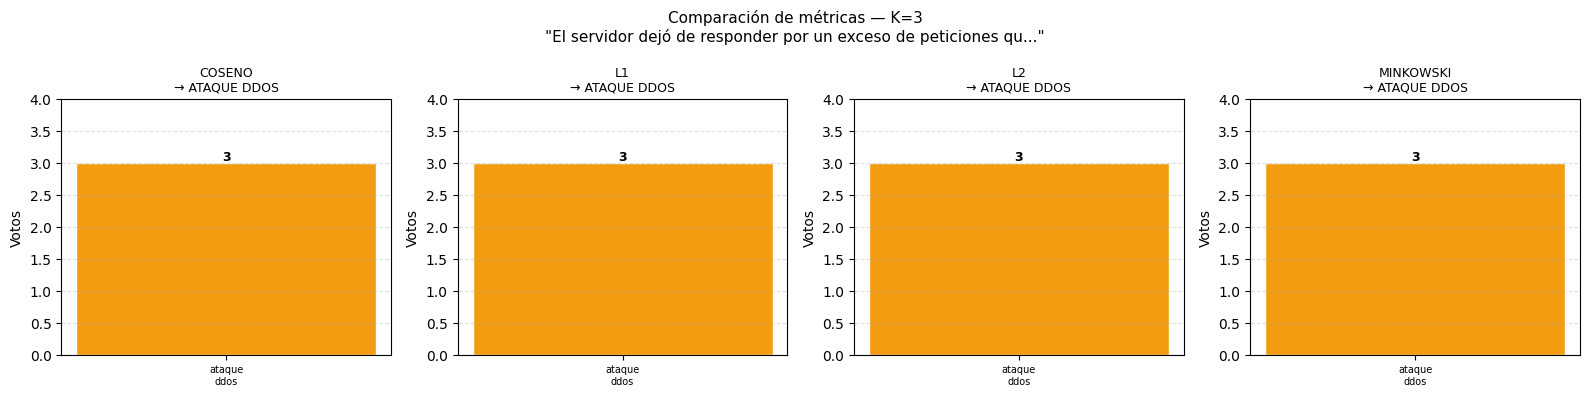

In [ ]:
# Paleta de colores por clase
PALETA_CLASES = {
    'phishing'            : '#e74c3c',
    'malware'             : '#3498db',
    'ataque_ddos'         : '#f39c12',
    'acceso_no_autorizado': '#2ecc71',
    'fuga_datos'          : '#9b59b6',
    'ingenieria_social'   : '#1abc9c'
}


def graficar_comparacion_metricas(mensaje, k=3):
    """
    Para un mismo mensaje, grafica los votos obtenidos
    con cada métrica (subplots lado a lado).
    """
    emb = modelo_interactivo.encode([mensaje])[0].tolist()
    metricas = ['coseno', 'l1', 'l2', 'minkowski']
    resultados_graf = []

    for m in metricas:
        pred, _, votos = knn_clasificar(emb, embeddings, clases, textos, k, m)
        resultados_graf.append((m, pred, votos))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    titulo_msg = mensaje[:60] + '...' if len(mensaje) > 60 else mensaje
    fig.suptitle(f'Comparación de métricas — K={k}\n"{titulo_msg}"', fontsize=11)

    for ax, (metrica, pred, votos) in zip(axes, resultados_graf):
        etiquetas = list(votos.keys())
        valores   = [votos[e] for e in etiquetas]
        cols      = [PALETA_CLASES.get(e, '#95a5a6') for e in etiquetas]
        barras    = ax.bar(range(len(etiquetas)), valores,
                           color=cols, edgecolor='white')
        ax.set_xticks(range(len(etiquetas)))
        ax.set_xticklabels([e.replace('_', '\n') for e in etiquetas],
                           fontsize=7, rotation=0)
        for barra, val in zip(barras, valores):
            ax.text(barra.get_x() + barra.get_width() / 2,
                    barra.get_height() + 0.05, str(val),
                    ha='center', fontsize=9, fontweight='bold')
        ax.set_title(f'{metrica.upper()}\n→ {pred.replace("_", " ").upper()}',
                     fontsize=9)
        ax.set_ylim(0, k + 1)
        ax.set_ylabel('Votos')
        ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()


# Probar con los mensajes de prueba
graficar_comparacion_metricas(
    'Recibí un correo del banco pidiendo que actualizara mi contraseña haciendo clic en un enlace', k=3)

graficar_comparacion_metricas(
    'El servidor dejó de responder por un exceso de peticiones que llegaron al mismo tiempo', k=3)

---
##  Resumen del sistema

| Componente | Descripción |
|---|---|
| **Dataset** | 90 muestras · 6 clases de incidentes · 15 muestras por clase |
| **Embeddings** | `paraphrase-multilingual-MiniLM-L12-v2` → vectores de 384 dim. |
| **Coseno** | Mide el ángulo entre vectores; ideal para textos en NLP |
| **L1** | Suma de diferencias absolutas; robusta ante outliers |
| **L2** | Distancia euclidiana; la más común en KNN clásico |
| **Minkowski** | Generalización de L1/L2 con parámetro `p=3` |
| **KNN** | Votación por mayoría entre los K vecinos más cercanos |
| **Evaluación** | Leave-One-Out para medir precisión real del clasificador |
